# 🩺 UPI Fraud & Healthcare Data Analysis
## Python Analysis — Fraud Detection & Anomaly Detection
**Tools:** Python · Pandas · Matplotlib · Scikit-learn  
**Dataset:** 8,000+ UPI healthcare transaction records  

### Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

In [2]:
import os
print("Notebook is running from:", os.getcwd())
print("Files in this folder:", os.listdir())

Notebook is running from: C:\Users\aishwarya\Desktop\UPI_Fraud_Healthcare_Data_Analysis
Files in this folder: ['.ipynb_checkpoints', 'Data', 'Excel', 'Power BI', 'Python', 'README.md.txt', 'Reports', 'SQL', 'sql_queries.sqbpro', 'upi_fraud_healthcare.db', 'upi_fraud_healthcare.sqbpro', 'upi_fraud_healthcare_analysis.ipynb', 'upi_fraud_healthcare_cleaned.csv']


### Step 2: Load the Dataset

In [3]:
df = pd.read_csv("upi_fraud_healthcare_cleaned.csv")
df.head()

,transaction_id,transaction_date,hospital_name,city,patient_age,gender,service_type,upi_app,amount,transaction_status,failure_reason,fraud_flag
0,TXN00001,2025-04-03,AIIMS,Kolkata,56,F,IPD,GPay,15753,Success,NaN,No
1,TXN00002,2024-09-09,Manipal,Delhi,35,F,Pharmacy,PhonePe,312,Success,NaN,No
2,TXN00003,2025-07-20,Manipal,Delhi,29,M,OPD,PhonePe,224,Success,NaN,No
3,TXN00004,2024-12-11,Narayana,Bangalore,40,F,Lab,Paytm,1168,Failed,Bank,No
4,TXN00005,2025-04-21,Apollo,Chennai,58,M,IPD,GPay,1333,Success,NaN,No


### Step 3: Inspect the Data

In [4]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (8000, 12)

Data types:
 transaction_id        object
transaction_date      object
hospital_name         object
city                  object
patient_age            int64
gender                object
service_type          object
upi_app               object
amount                 int64
transaction_status    object
failure_reason        object
fraud_flag            object
dtype: object

Missing values:
 transaction_id           0
transaction_date         0
hospital_name            0
city                     0
patient_age              0
gender                   0
service_type             0
upi_app                  0
amount                   0
transaction_status       0
failure_reason        6266
fraud_flag               0
dtype: int64


### Step 4: Data Cleaning

In [5]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="mixed", dayfirst=True)
df["fraud_flag_num"] = (df["fraud_flag"] == "Yes").astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      8000 non-null   object        
 1   transaction_date    8000 non-null   datetime64[ns]
 2   hospital_name       8000 non-null   object        
 3   city                8000 non-null   object        
 4   patient_age         8000 non-null   int64         
 5   gender              8000 non-null   object        
 6   service_type        8000 non-null   object        
 7   upi_app             8000 non-null   object        
 8   amount              8000 non-null   int64         
 9   transaction_status  8000 non-null   object        
 10  failure_reason      1734 non-null   object        
 11  fraud_flag          8000 non-null   object        
 12  fraud_flag_num      8000 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(9)
memory

### Step 5: Exploratory Data Analysis — Fraud by Hospital

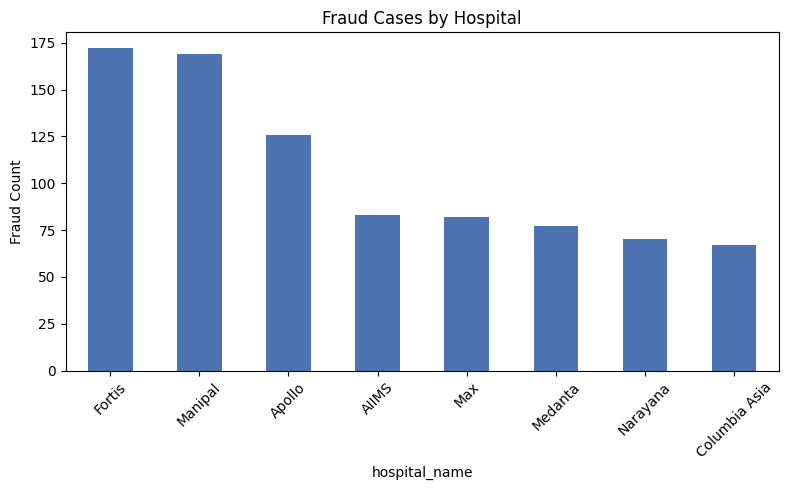

In [6]:
fraud_hospital = df[df["fraud_flag"] == "Yes"].groupby("hospital_name").size().sort_values(ascending=False)
fraud_hospital.plot(kind="bar", figsize=(8,5), color="#4C72B0")
plt.title("Fraud Cases by Hospital")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 6: Exploratory Data Analysis — Fraud by UPI App

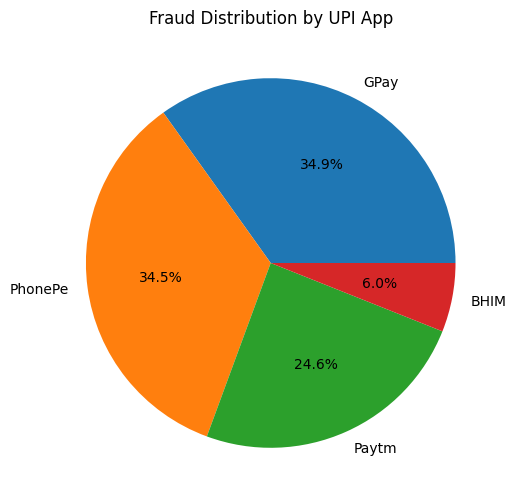

In [7]:
fraud_upi = df[df["fraud_flag"] == "Yes"]["upi_app"].value_counts()
fraud_upi.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Fraud Distribution by UPI App")
plt.ylabel("")
plt.show()

### Step 7: Exploratory Data Analysis — Monthly Fraud Trend

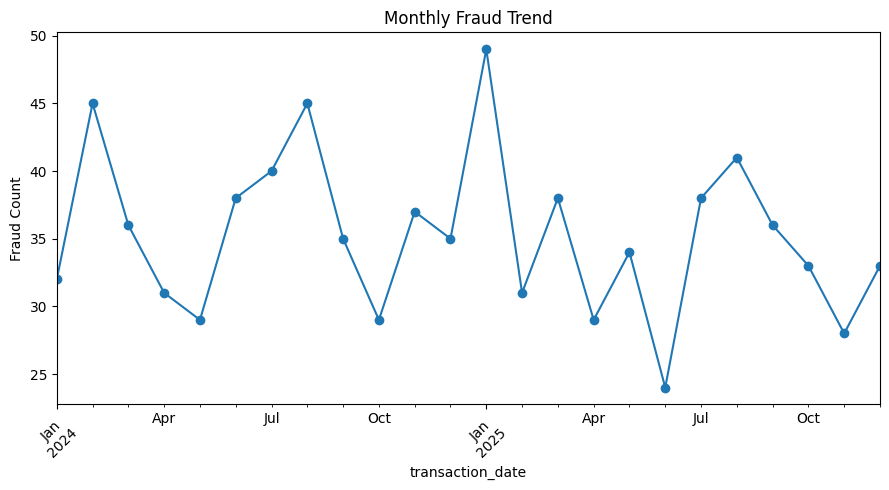

In [8]:
monthly_fraud = df[df["fraud_flag"] == "Yes"].groupby(df["transaction_date"].dt.to_period("M")).size()
monthly_fraud.plot(kind="line", marker="o", figsize=(9,5))
plt.title("Monthly Fraud Trend")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 8: Fraud Rate by City

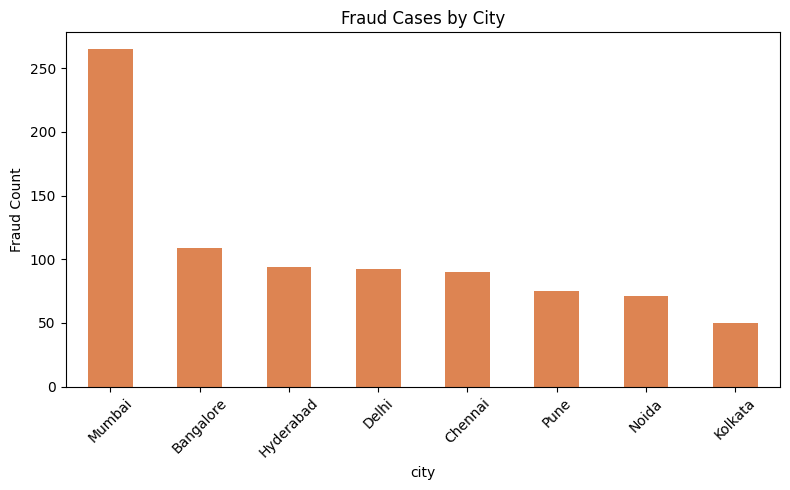

In [9]:
fraud_city = df[df["fraud_flag"] == "Yes"]["city"].value_counts()
fraud_city.plot(kind="bar", figsize=(8,5), color="#DD8452")
plt.title("Fraud Cases by City")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 9: Correlation Analysis

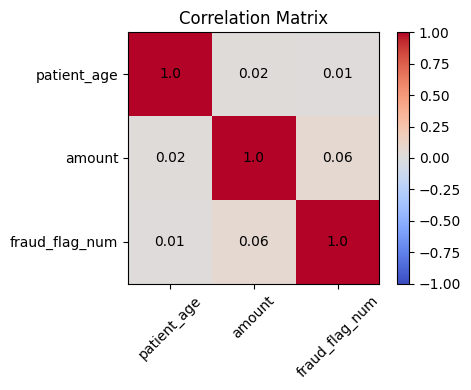

In [10]:
numeric_df = df[["patient_age", "amount", "fraud_flag_num"]]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, round(corr.iloc[i,j], 2), ha="center", va="center")
plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Step 10: Feature Preparation for Modeling

In [11]:
features = ["hospital_name", "city", "patient_age", "gender", "service_type", "upi_app", "amount", "transaction_status"]
X = df[features].copy()
y = df["fraud_flag_num"]

cat_cols = ["hospital_name", "city", "gender", "service_type", "upi_app", "transaction_status"]
for c in cat_cols:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))

X.head()

,hospital_name,city,patient_age,gender,service_type,upi_app,amount,transaction_status
0,0,4,56,0,0,1,15753,1
1,4,2,35,0,3,3,312,1
2,4,2,29,1,2,3,224,1
3,7,0,40,0,1,2,1168,0
4,1,1,58,1,0,1,1333,1


### Step 11: Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], " | Test size:", X_test.shape[0])

Train size: 6400  | Test size: 1600


### Step 12: Train the Fraud Detection Model (Logistic Regression)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)
probs = model.predict_proba(X_test_scaled)[:, 1]

### Step 13: Model Evaluation

In [14]:
print(classification_report(y_test, preds, target_names=["Not Fraud", "Fraud"]))
print("ROC-AUC:", round(roc_auc_score(y_test, probs), 3))

              precision    recall  f1-score   support

   Not Fraud       0.93      0.78      0.84      1431
       Fraud       0.20      0.48      0.28       169

    accuracy                           0.74      1600
   macro avg       0.56      0.63      0.56      1600
weighted avg       0.85      0.74      0.79      1600

ROC-AUC: 0.636


### Step 14: Confusion Matrix & ROC Curve

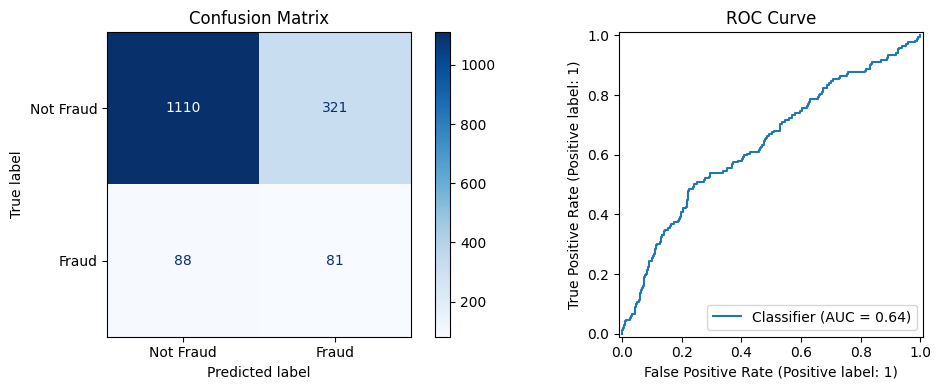

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=["Not Fraud","Fraud"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, probs, ax=axes[1])
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

### Step 15: Feature Importance

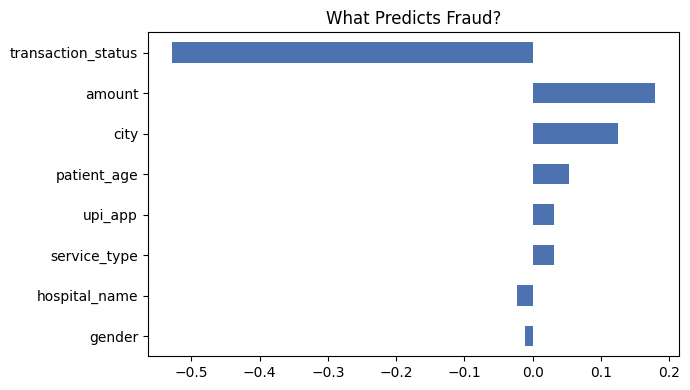

In [16]:
importances = pd.Series(model.coef_[0], index=features).sort_values(key=abs, ascending=False)
importances.plot(kind="barh", figsize=(7,4), color="#4C72B0")
plt.title("What Predicts Fraud?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Step 16: Unsupervised Anomaly Detection (Isolation Forest)

In [17]:
iso = IsolationForest(contamination=0.106, random_state=42)  # matches actual fraud rate in this dataset
iso_preds = iso.fit_predict(X)
df["anomaly_flag"] = (iso_preds == -1).astype(int)

overlap = pd.crosstab(df["fraud_flag_num"], df["anomaly_flag"], rownames=["Actual Fraud"], colnames=["Flagged Anomaly"])
print(overlap)

Flagged Anomaly     0    1
Actual Fraud              
0                6448  706
1                 704  142


## Conclusion

This project analyzed 8,000 UPI healthcare transactions using SQL, Python, and Power BI to detect and understand fraud patterns.

**Key findings:**
- Overall fraud rate: ~10.6%
- Fraud is concentrated in failed transactions, high-value payments, and specific hospitals/cities (see SQL and EDA sections above)
- `transaction_status` (failed vs. successful) was the single strongest predictor of fraud

**Model performance:**
- Logistic Regression (supervised): ROC-AUC of 0.64, recall of 48% and precision of 20% for the fraud class — meaning it catches under half of fraud cases, with a high false-alarm rate
- Isolation Forest (unsupervised, no labels used): flagged anomalies overlapped with only ~17% of actual fraud cases — weaker than the supervised approach

**Interpretation:** transaction metadata alone provides a modest, but real, fraud signal (better than random guessing at ROC-AUC 0.64) — not enough for a hands-off automated system, but useful as one input into a broader fraud-review process alongside manual checks.

**Limitations:**
- Dataset is synthetically generated for portfolio purposes, not real transaction data
- No behavioral/device-level features (transaction frequency, device ID, location history) — these typically matter more than metadata alone in real fraud systems
- Class imbalance (~10.6% fraud) makes precision/recall trade-offs unavoidable without more features or data

**Next steps for a production system:** richer behavioral features, ensemble models (e.g. XGBoost), and a larger, real-world labeled dataset would likely improve results substantially over this baseline.